# Simple Vanilla KD

## 1. Imports

In [5]:
import os
import json
import time
import random
import shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.optim.lr_scheduler import MultiStepLR
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from torch.cuda.amp import autocast, GradScaler

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch version: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [6]:
KAGGLE_WORKING = Path("/kaggle/working")
KAGGLE_INPUT = Path("/kaggle/input")
BASE_OUTPUT_DIR = KAGGLE_WORKING if KAGGLE_WORKING.exists() else Path.cwd() / "outputs"

CONFIG = {
    "model": "resnet20",
    "teacher_model": "resnet110",
    "dataset": "CIFAR100",
    "num_classes": 100,
    "epochs": 200,
    "batch_size": 128,
    "optimizer": "SGD",
    "learning_rate": 0.1,
    "momentum": 0.9,
    "weight_decay": 0.0005,
    "scheduler": "MultiStepLR",
    "milestones": [100, 150],
    "gamma": 0.1,
    "temperature": 4.0,
    "alpha": 0.7,
    "loss": "CrossEntropy + KLDiv Distillation",
    "teacher_checkpoint": "ekd_paper_teacher_resnet110_best.pth",
    "student_ce_checkpoint": "student_resnet20_ce_best.pth",
    "teacher_input_dir": "/kaggle/input/models/muhammadzaidiftikhar/ekd-teacher/pytorch/default/1",
    "teacher_input_dir_fallback": "/kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110/pytorch/default/1",
    "teacher_artifact_stage_dir": "ekd_paper_teacher_resnet110",
    "student_ce_input_dir": "/kaggle/input/models/muhammadzaidiftikhar/student-ce/pytorch/default/1",
    "student_initialization": "from_scratch",
    "seed": 42,
    "mixed_precision": True,
    "num_workers": 2,
    "pin_memory": True,
    "run_main_kd": True,
    "run_temperature_ablation": False,
    "temperature_values": [1.0, 2.0, 4.0, 8.0],
    "run_alpha_ablation": False,
    "alpha_values": [0.3, 0.5, 0.7, 0.9],
    "ablation_epochs": 200,
    "quick_sanity_check": False,
    "sanity_epochs": 1,
    "output_root": str(BASE_OUTPUT_DIR / "kd_cifar100_artifacts"),
    "stage_dir": "simple_kd_with_ekd_teacher",
}

if CONFIG["quick_sanity_check"]:
    CONFIG["epochs"] = CONFIG["sanity_epochs"]
    CONFIG["ablation_epochs"] = CONFIG["sanity_epochs"]
    CONFIG["run_temperature_ablation"] = False
    CONFIG["run_alpha_ablation"] = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
CONFIG

Using device: cuda


{'model': 'resnet20',
 'teacher_model': 'resnet110',
 'dataset': 'CIFAR100',
 'num_classes': 100,
 'epochs': 200,
 'batch_size': 128,
 'optimizer': 'SGD',
 'learning_rate': 0.1,
 'momentum': 0.9,
 'weight_decay': 0.0005,
 'scheduler': 'MultiStepLR',
 'milestones': [100, 150],
 'gamma': 0.1,
 'temperature': 4.0,
 'alpha': 0.7,
 'loss': 'CrossEntropy + KLDiv Distillation',
 'teacher_checkpoint': 'ekd_paper_teacher_resnet110_best.pth',
 'student_ce_checkpoint': 'student_resnet20_ce_best.pth',
 'teacher_input_dir': '/kaggle/input/models/muhammadzaidiftikhar/ekd-teacher/pytorch/default/1',
 'teacher_input_dir_fallback': '/kaggle/input/models/zaidiftikhar/ekd-paper-teacher-resnet110/pytorch/default/1',
 'teacher_artifact_stage_dir': 'ekd_paper_teacher_resnet110',
 'student_ce_input_dir': '/kaggle/input/models/muhammadzaidiftikhar/student-ce/pytorch/default/1',
 'student_initialization': 'from_scratch',
 'seed': 42,
 'mixed_precision': True,
 'num_workers': 2,
 'pin_memory': True,
 'run_main_

## 3. Reproducibility and Output Directories

In [7]:
def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.benchmark = False
    torch.backends.cudnn.deterministic = True


set_seed(CONFIG["seed"])

stage_root = Path(CONFIG["output_root"]) / CONFIG["stage_dir"]
checkpoint_dir = stage_root / "checkpoints"
log_dir = stage_root / "logs"
config_dir = stage_root / "config"
plot_dir = stage_root / "plots"
table_dir = stage_root / "tables"
analysis_dir = stage_root / "analysis"

for directory in [checkpoint_dir, log_dir, config_dir, plot_dir, table_dir, analysis_dir]:
    directory.mkdir(parents=True, exist_ok=True)

config_path = config_dir / "simple_kd_with_ekd_teacher_config.json"
with open(config_path, "w") as f:
    json.dump(CONFIG, f, indent=4)

print(f"Artifacts directory: {stage_root}")
print(f"Saved config: {config_path}")

Artifacts directory: /kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher
Saved config: /kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/config/simple_kd_with_ekd_teacher_config.json


## 4. CIFAR-100 Dataset and DataLoaders

In [8]:
CIFAR100_MEAN = (0.5071, 0.4867, 0.4408)
CIFAR100_STD = (0.2675, 0.2565, 0.2761)

train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

plain_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(CIFAR100_MEAN, CIFAR100_STD),
])

data_root = KAGGLE_WORKING / "data" if KAGGLE_WORKING.exists() else Path("./data")
download_dataset = True

train_dataset = datasets.CIFAR100(root=str(data_root), train=True, download=download_dataset, transform=train_transform)
test_dataset = datasets.CIFAR100(root=str(data_root), train=False, download=download_dataset, transform=test_transform)
analysis_dataset = datasets.CIFAR100(root=str(data_root), train=False, download=download_dataset, transform=plain_transform)

train_loader = DataLoader(
    train_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=True,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
)

test_loader = DataLoader(
    test_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
)

analysis_loader = DataLoader(
    analysis_dataset,
    batch_size=CONFIG["batch_size"],
    shuffle=False,
    num_workers=CONFIG["num_workers"],
    pin_memory=CONFIG["pin_memory"] and torch.cuda.is_available(),
)

class_names = train_dataset.classes
print(f"Train samples: {len(train_dataset)}")
print(f"Test samples: {len(test_dataset)}")
print(f"Classes: {len(class_names)}")

Train samples: 50000
Test samples: 10000
Classes: 100


## 5. CIFAR-Style ResNet Implementation

In [9]:
class BasicBlock(nn.Module):
    expansion = 1

    def __init__(self, in_planes, planes, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_planes, planes, kernel_size=3, stride=stride, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(planes)
        self.conv2 = nn.Conv2d(planes, planes, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn2 = nn.BatchNorm2d(planes)

        if stride != 1 or in_planes != planes * self.expansion:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_planes, planes * self.expansion, kernel_size=1, stride=stride, bias=False),
                nn.BatchNorm2d(planes * self.expansion),
            )
        else:
            self.shortcut = nn.Identity()

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.bn2(self.conv2(out))
        out = out + self.shortcut(x)
        out = F.relu(out, inplace=True)
        return out


class CIFARResNet(nn.Module):
    def __init__(self, block, num_blocks, num_classes=100):
        super().__init__()
        self.in_planes = 16
        self.conv1 = nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1, bias=False)
        self.bn1 = nn.BatchNorm2d(16)
        self.layer1 = self._make_layer(block, 16, num_blocks[0], stride=1)
        self.layer2 = self._make_layer(block, 32, num_blocks[1], stride=2)
        self.layer3 = self._make_layer(block, 64, num_blocks[2], stride=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.fc = nn.Linear(64 * block.expansion, num_classes)
        self._initialize_weights()

    def _make_layer(self, block, planes, num_blocks, stride):
        strides = [stride] + [1] * (num_blocks - 1)
        layers = []
        for block_stride in strides:
            layers.append(block(self.in_planes, planes, block_stride))
            self.in_planes = planes * block.expansion
        return nn.Sequential(*layers)

    def _initialize_weights(self):
        for module in self.modules():
            if isinstance(module, nn.Conv2d):
                nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            elif isinstance(module, nn.BatchNorm2d):
                nn.init.constant_(module.weight, 1)
                nn.init.constant_(module.bias, 0)
            elif isinstance(module, nn.Linear):
                nn.init.kaiming_normal_(module.weight)
                nn.init.constant_(module.bias, 0)

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)), inplace=True)
        out = self.layer1(out)
        out = self.layer2(out)
        out = self.layer3(out)
        out = self.avgpool(out)
        out = torch.flatten(out, 1)
        out = self.fc(out)
        return out


def resnet20(num_classes=100):
    return CIFARResNet(BasicBlock, [3, 3, 3], num_classes=num_classes)


def resnet110(num_classes=100):
    return CIFARResNet(BasicBlock, [18, 18, 18], num_classes=num_classes)

## 6. Locate and Load Previous Stage Checkpoints

In [10]:
def find_checkpoint(filename, preferred_stage_dir, explicit_input_dir=None, extra_input_dirs=None):
    search_roots = []
    if explicit_input_dir:
        search_roots.append(Path(explicit_input_dir))
    if extra_input_dirs:
        for extra_dir in extra_input_dirs:
            if extra_dir:
                search_roots.append(Path(extra_dir))
    if KAGGLE_INPUT.exists():
        search_roots.extend(sorted(KAGGLE_INPUT.glob("*")))
    search_roots.extend([
        Path(CONFIG["output_root"]),
        Path.cwd() / "kd_cifar100_artifacts",
        Path.cwd() / "outputs" / "kd_cifar100_artifacts",
    ])

    candidates = []
    for root in search_roots:
        if not root.exists():
            continue
        direct_patterns = [
            root / preferred_stage_dir / "checkpoints" / filename,
            root / CONFIG.get("teacher_artifact_stage_dir", preferred_stage_dir) / "checkpoints" / filename,
            root / "checkpoints" / filename,
            root / filename,
        ]
        candidates.extend([p for p in direct_patterns if p.exists()])
        candidates.extend(root.rglob(filename))

    unique = []
    seen = set()
    for path in candidates:
        resolved = path.resolve()
        if resolved not in seen:
            seen.add(resolved)
            unique.append(path)

    if not unique:
        raise FileNotFoundError(
            f"Could not find {filename}. Attach the previous notebook output as a Kaggle input "
            f"or place it under kd_cifar100_artifacts/{preferred_stage_dir}/checkpoints/."
        )
    return unique[0]


def remap_official_resnet_keys(state_dict):
    # EKD teacher notebooks use official mdistiller ResNet names: layer*.0.downsample.*
    # This notebook's CIFARResNet uses local names: layer*.0.shortcut.*
    remapped = {}
    for key, value in state_dict.items():
        new_key = key
        new_key = new_key.replace("layer2.0.downsample.", "layer2.0.shortcut.")
        new_key = new_key.replace("layer3.0.downsample.", "layer3.0.shortcut.")
        remapped[new_key] = value
    return remapped


def extract_state_dict(checkpoint):
    if isinstance(checkpoint, dict):
        for key in ["model_state_dict", "student_state_dict", "state_dict"]:
            if key in checkpoint and isinstance(checkpoint[key], dict):
                return checkpoint[key]
        if "model" in checkpoint and isinstance(checkpoint["model"], dict):
            return checkpoint["model"]
    return checkpoint


def load_checkpoint_into_model(model, checkpoint_path, device):
    checkpoint = torch.load(checkpoint_path, map_location=device)
    state_dict = extract_state_dict(checkpoint)
    try:
        model.load_state_dict(state_dict)
    except RuntimeError:
        remapped_state_dict = remap_official_resnet_keys(state_dict)
        model.load_state_dict(remapped_state_dict)
        print("Loaded checkpoint after remapping official ResNet downsample keys to local shortcut keys.")
    return checkpoint


teacher_checkpoint_path = find_checkpoint(
    CONFIG["teacher_checkpoint"],
    CONFIG["teacher_artifact_stage_dir"],
    explicit_input_dir=CONFIG["teacher_input_dir"],
    extra_input_dirs=[CONFIG.get("teacher_input_dir_fallback")],
)
student_ce_checkpoint_path = find_checkpoint(
    CONFIG["student_ce_checkpoint"],
    "student_resnet20_ce",
    explicit_input_dir=CONFIG["student_ce_input_dir"],
)

print(f"Teacher checkpoint: {teacher_checkpoint_path}")
print(f"CE student checkpoint: {student_ce_checkpoint_path}")

teacher = resnet110(num_classes=CONFIG["num_classes"]).to(device)
teacher_ckpt = load_checkpoint_into_model(teacher, teacher_checkpoint_path, device)
teacher.eval()
for param in teacher.parameters():
    param.requires_grad = False

student_ce = resnet20(num_classes=CONFIG["num_classes"]).to(device)
student_ce_ckpt = load_checkpoint_into_model(student_ce, student_ce_checkpoint_path, device)
student_ce.eval()

teacher_best_from_ckpt = teacher_ckpt.get("best_acc", None) if isinstance(teacher_ckpt, dict) else None
student_ce_best_from_ckpt = student_ce_ckpt.get("best_acc", None) if isinstance(student_ce_ckpt, dict) else None
print(f"Teacher checkpoint best_acc: {teacher_best_from_ckpt}")
print(f"CE student checkpoint best_acc: {student_ce_best_from_ckpt}")

Teacher checkpoint: /kaggle/input/models/muhammadzaidiftikhar/ekd-teacher/pytorch/default/1/ekd_paper_teacher_resnet110_best.pth
CE student checkpoint: /kaggle/input/models/muhammadzaidiftikhar/student-ce/pytorch/default/1/student_resnet20_ce_best.pth
Loaded checkpoint after remapping official ResNet downsample keys to local shortcut keys.
Teacher checkpoint best_acc: 73.69
CE student checkpoint best_acc: 69.47


## 7. Evaluation and Distillation Utilities

In [11]:
def accuracy_from_logits(logits, labels):
    predictions = logits.argmax(dim=1)
    return predictions.eq(labels).sum().item()


@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    running_loss = 0.0
    running_correct = 0
    running_total = 0
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = F.cross_entropy(logits, labels)
        batch_size = labels.size(0)
        running_loss += loss.item() * batch_size
        running_correct += accuracy_from_logits(logits, labels)
        running_total += batch_size
    return running_loss / running_total, 100.0 * running_correct / running_total


def kd_loss_fn(student_logits, teacher_logits, labels, temperature, alpha):
    ce_loss = F.cross_entropy(student_logits, labels)
    student_log_probs = F.log_softmax(student_logits / temperature, dim=1)
    teacher_probs = F.softmax(teacher_logits / temperature, dim=1)
    kd_loss = F.kl_div(student_log_probs, teacher_probs, reduction="batchmean") * (temperature * temperature)
    total_loss = (1.0 - alpha) * ce_loss + alpha * kd_loss
    return total_loss, ce_loss.detach(), kd_loss.detach()


def save_checkpoint(path, epoch, model, optimizer, scheduler, best_acc, config, train_dataset):
    checkpoint = {
        "epoch": epoch,
        "model_name": config["model"],
        "teacher_model": config["teacher_model"],
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
        "scheduler_state_dict": scheduler.state_dict(),
        "best_acc": best_acc,
        "config": config,
        "class_to_idx": train_dataset.class_to_idx,
        "classes": train_dataset.classes,
    }
    torch.save(checkpoint, path)


def experiment_name(temperature, alpha):
    t = str(int(temperature)) if float(temperature).is_integer() else str(temperature).replace('.', '')
    a = f"{int(round(alpha * 10)):02d}"
    return f"student_resnet20_kd_T{t}_a{a}"

## 8. KD Training Function

In [12]:
def train_kd_experiment(temperature, alpha, epochs, run_name=None):
    set_seed(CONFIG["seed"])
    run_name = run_name or experiment_name(temperature, alpha)
    run_config = CONFIG.copy()
    run_config.update({"temperature": temperature, "alpha": alpha, "epochs": epochs, "run_name": run_name})

    student = resnet20(num_classes=CONFIG["num_classes"]).to(device)
    optimizer = optim.SGD(
        student.parameters(),
        lr=CONFIG["learning_rate"],
        momentum=CONFIG["momentum"],
        weight_decay=CONFIG["weight_decay"],
    )
    scheduler = MultiStepLR(optimizer, milestones=CONFIG["milestones"], gamma=CONFIG["gamma"])
    scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())

    best_path = checkpoint_dir / f"{run_name}_best.pth"
    last_path = checkpoint_dir / f"{run_name}_last.pth"
    log_path = log_dir / f"{run_name}_log.csv"
    run_config_path = config_dir / f"{run_name}_config.json"
    with open(run_config_path, "w") as f:
        json.dump(run_config, f, indent=4)

    log_records = []
    best_acc = 0.0
    start_time = time.time()

    for epoch in range(1, epochs + 1):
        epoch_start = time.time()
        student.train()
        running_total_loss = 0.0
        running_ce_loss = 0.0
        running_kd_loss = 0.0
        running_correct = 0
        running_total = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            with torch.no_grad():
                teacher_logits = teacher(images)

            with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):
                student_logits = student(images)
                loss, ce_loss, kd_loss = kd_loss_fn(student_logits, teacher_logits, labels, temperature, alpha)

            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            batch_size = labels.size(0)
            running_total_loss += loss.item() * batch_size
            running_ce_loss += ce_loss.item() * batch_size
            running_kd_loss += kd_loss.item() * batch_size
            running_correct += accuracy_from_logits(student_logits, labels)
            running_total += batch_size

        train_loss = running_total_loss / running_total
        train_ce_loss = running_ce_loss / running_total
        train_kd_loss = running_kd_loss / running_total
        train_acc = 100.0 * running_correct / running_total
        test_loss, test_acc = evaluate(student, test_loader, device)
        current_lr = optimizer.param_groups[0]["lr"]
        scheduler.step()

        if test_acc > best_acc:
            best_acc = test_acc
            save_checkpoint(best_path, epoch, student, optimizer, scheduler, best_acc, run_config, train_dataset)

        save_checkpoint(last_path, epoch, student, optimizer, scheduler, best_acc, run_config, train_dataset)

        epoch_time = time.time() - epoch_start
        record = {
            "epoch": epoch,
            "lr": current_lr,
            "temperature": temperature,
            "alpha": alpha,
            "train_loss": train_loss,
            "train_ce_loss": train_ce_loss,
            "train_kd_loss": train_kd_loss,
            "train_acc": train_acc,
            "test_loss": test_loss,
            "test_acc": test_acc,
            "best_test_acc": best_acc,
            "epoch_time_sec": epoch_time,
        }
        log_records.append(record)
        pd.DataFrame(log_records).to_csv(log_path, index=False)

        print(
            f"{run_name} | Epoch {epoch:03d}/{epochs:03d} | lr {current_lr:.5f} | "
            f"train {train_loss:.4f}, acc {train_acc:.2f}% | "
            f"test {test_loss:.4f}, acc {test_acc:.2f}% | best {best_acc:.2f}% | "
            f"time {epoch_time:.1f}s"
        )

    training_time = time.time() - start_time
    final_acc = log_records[-1]["test_acc"]
    return {
        "run_name": run_name,
        "temperature": temperature,
        "alpha": alpha,
        "epochs": epochs,
        "best_test_accuracy": best_acc,
        "final_test_accuracy": final_acc,
        "training_time_sec": training_time,
        "best_checkpoint": str(best_path),
        "last_checkpoint": str(last_path),
        "log_path": str(log_path),
        "config_path": str(run_config_path),
    }

## 9. Evaluate Loaded Teacher and CE Student

In [13]:
teacher_test_loss, teacher_test_acc = evaluate(teacher, test_loader, device)
student_ce_test_loss, student_ce_test_acc = evaluate(student_ce, test_loader, device)

print(f"Teacher ResNet-110 test accuracy: {teacher_test_acc:.2f}%")
print(f"CE Student ResNet-20 test accuracy: {student_ce_test_acc:.2f}%")
print(f"Teacher-student CE gap: {teacher_test_acc - student_ce_test_acc:.2f} points")

Teacher ResNet-110 test accuracy: 73.69%
CE Student ResNet-20 test accuracy: 69.47%
Teacher-student CE gap: 4.22 points


## 10. Main KD Run

In [14]:
main_kd_result = None
if CONFIG["run_main_kd"]:
    main_run_name = experiment_name(CONFIG["temperature"], CONFIG["alpha"])
    main_kd_result = train_kd_experiment(
        temperature=CONFIG["temperature"],
        alpha=CONFIG["alpha"],
        epochs=CONFIG["epochs"],
        run_name=main_run_name,
    )
    print(main_kd_result)
else:
    print("Main KD training skipped by config.")

/tmp/ipykernel_57/3176540561.py:15: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available())
/tmp/ipykernel_57/3176540561.py:45: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast(enabled=CONFIG["mixed_precision"] and torch.cuda.is_available()):


student_resnet20_kd_T4_a07 | Epoch 001/200 | lr 0.10000 | train 11.7276, acc 8.63% | test 4.3066, acc 11.60% | best 11.60% | time 21.2s
student_resnet20_kd_T4_a07 | Epoch 002/200 | lr 0.10000 | train 9.5929, acc 19.43% | test 4.1981, acc 20.70% | best 20.70% | time 20.6s
student_resnet20_kd_T4_a07 | Epoch 003/200 | lr 0.10000 | train 8.1058, acc 27.77% | test 3.5693, acc 28.68% | best 28.68% | time 20.9s
student_resnet20_kd_T4_a07 | Epoch 004/200 | lr 0.10000 | train 7.1356, acc 34.59% | test 3.6204, acc 29.95% | best 29.95% | time 21.5s
student_resnet20_kd_T4_a07 | Epoch 005/200 | lr 0.10000 | train 6.3592, acc 39.60% | test 3.1074, acc 35.66% | best 35.66% | time 21.9s
student_resnet20_kd_T4_a07 | Epoch 006/200 | lr 0.10000 | train 5.8246, acc 43.51% | test 3.2624, acc 37.38% | best 37.38% | time 21.9s
student_resnet20_kd_T4_a07 | Epoch 007/200 | lr 0.10000 | train 5.4676, acc 46.37% | test 2.9289, acc 42.46% | best 42.46% | time 21.6s
student_resnet20_kd_T4_a07 | Epoch 008/200 | lr 

## 11. Temperature Ablation

In [15]:
temperature_results = []

if CONFIG["run_temperature_ablation"]:
    for temperature in CONFIG["temperature_values"]:
        run_name = experiment_name(temperature, CONFIG["alpha"])
        existing_main = main_kd_result and run_name == main_kd_result["run_name"]
        if existing_main:
            result = main_kd_result.copy()
            print(f"Reusing main KD result for {run_name}")
        else:
            result = train_kd_experiment(
                temperature=temperature,
                alpha=CONFIG["alpha"],
                epochs=CONFIG["ablation_epochs"],
                run_name=run_name,
            )
        result["teacher_student_gap"] = teacher_test_acc - result["best_test_accuracy"]
        temperature_results.append(result)

temperature_df = pd.DataFrame(temperature_results)
temperature_path = log_dir / "temperature_ablation_results.csv"
temperature_df.to_csv(temperature_path, index=False)
display(temperature_df)
print(f"Saved temperature ablation results: {temperature_path}")

""


Saved temperature ablation results: /kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/logs/temperature_ablation_results.csv


## 12. Alpha Ablation

In [16]:
alpha_results = []

if CONFIG["run_alpha_ablation"]:
    best_temperature = CONFIG["temperature"]
    if not temperature_df.empty:
        best_temperature = float(temperature_df.sort_values("best_test_accuracy", ascending=False).iloc[0]["temperature"])

    for alpha in CONFIG["alpha_values"]:
        run_name = experiment_name(best_temperature, alpha)
        existing_main = main_kd_result and run_name == main_kd_result["run_name"]
        if existing_main:
            result = main_kd_result.copy()
            print(f"Reusing main KD result for {run_name}")
        else:
            result = train_kd_experiment(
                temperature=best_temperature,
                alpha=alpha,
                epochs=CONFIG["ablation_epochs"],
                run_name=run_name,
            )
        result["teacher_student_gap"] = teacher_test_acc - result["best_test_accuracy"]
        alpha_results.append(result)

alpha_df = pd.DataFrame(alpha_results)
alpha_path = log_dir / "alpha_ablation_results.csv"
alpha_df.to_csv(alpha_path, index=False)
display(alpha_df)
print(f"Saved alpha ablation results: {alpha_path}")

""


Saved alpha ablation results: /kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/logs/alpha_ablation_results.csv


## 13. Load Best KD Student

In [17]:
if main_kd_result is None:
    if temperature_results:
        main_kd_result = max(temperature_results, key=lambda item: item["best_test_accuracy"])
    else:
        raise RuntimeError("No KD student has been trained. Enable run_main_kd or run_temperature_ablation.")

student_kd = resnet20(num_classes=CONFIG["num_classes"]).to(device)
kd_ckpt = load_checkpoint_into_model(student_kd, main_kd_result["best_checkpoint"], device)
student_kd.eval()
student_kd_test_loss, student_kd_test_acc = evaluate(student_kd, test_loader, device)

print(f"Loaded KD checkpoint: {main_kd_result['best_checkpoint']}")
print(f"KD Student ResNet-20 test accuracy: {student_kd_test_acc:.2f}%")

Loaded KD checkpoint: /kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/checkpoints/student_resnet20_kd_T4_a07_best.pth
KD Student ResNet-20 test accuracy: 71.25%


## 17. Plots

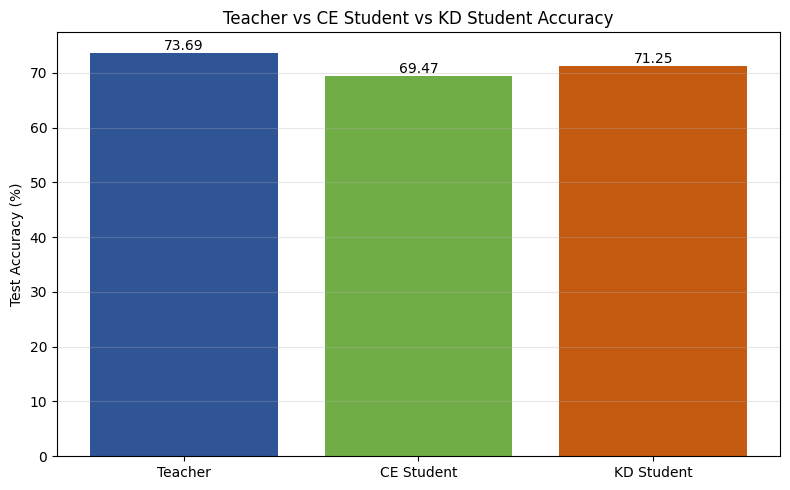

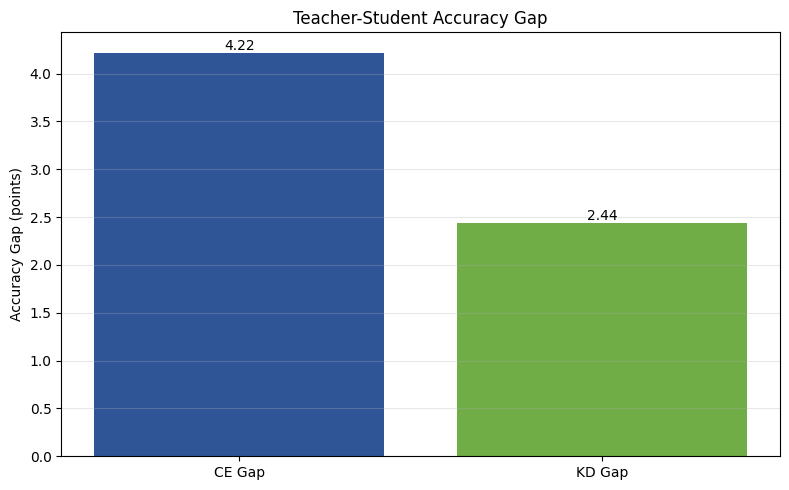

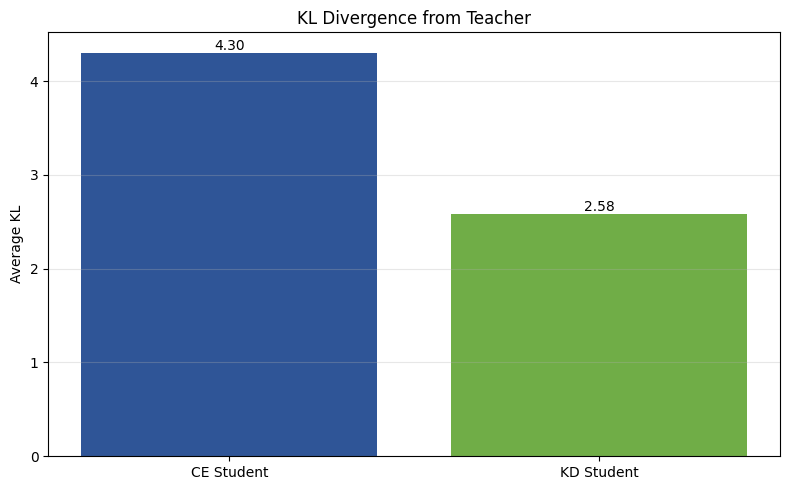

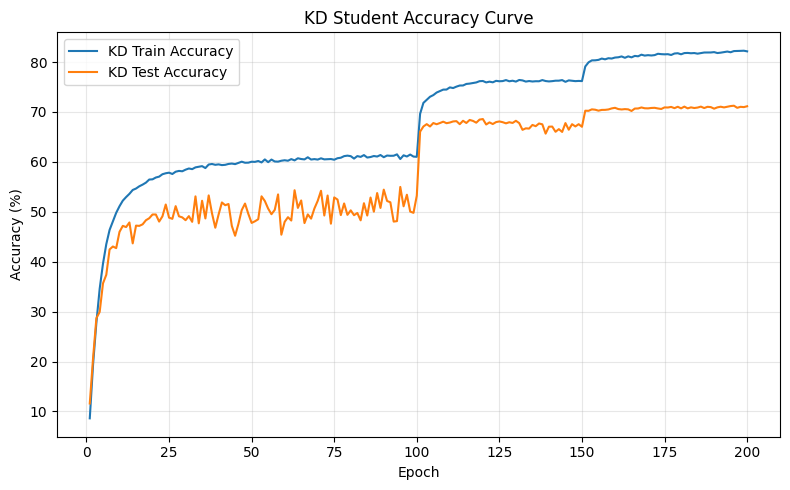

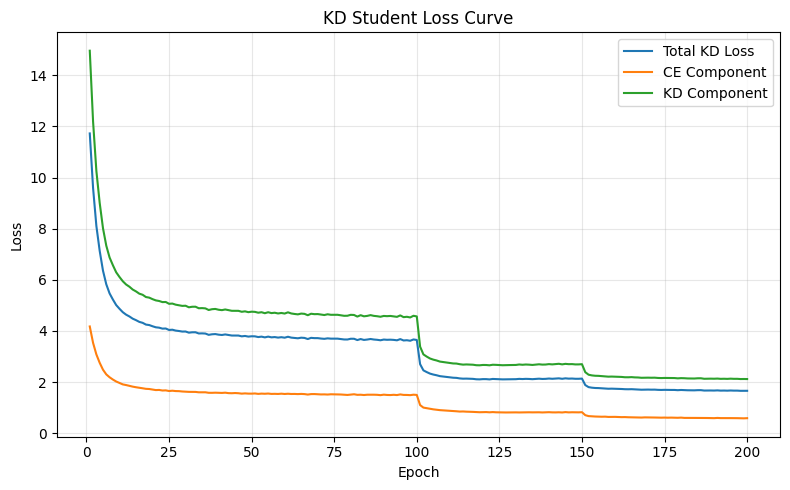

In [21]:
def save_bar_chart(labels, values, title, ylabel, path):
    plt.figure(figsize=(8, 5))
    bars = plt.bar(labels, values, color=["#2F5597", "#70AD47", "#C55A11"][:len(labels)])
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(axis="y", alpha=0.3)
    for bar, value in zip(bars, values):
        plt.text(bar.get_x() + bar.get_width() / 2, value, f"{value:.2f}", ha="center", va="bottom")
    plt.tight_layout()
    plt.savefig(path, dpi=200)
    plt.show()


save_bar_chart(
    ["Teacher", "CE Student", "KD Student"],
    [teacher_test_acc, student_ce_test_acc, student_kd_test_acc],
    "Teacher vs CE Student vs KD Student Accuracy",
    "Test Accuracy (%)",
    plot_dir / "teacher_ce_kd_accuracy_bar.png",
)

save_bar_chart(
    ["CE Gap", "KD Gap"],
    [teacher_test_acc - student_ce_test_acc, teacher_test_acc - student_kd_test_acc],
    "Teacher-Student Accuracy Gap",
    "Accuracy Gap (points)",
    plot_dir / "teacher_student_gap.png",
)

save_bar_chart(
    ["CE Student", "KD Student"],
    [ce_alignment["avg_kl_teacher_to_student"], kd_alignment["avg_kl_teacher_to_student"]],
    "KL Divergence from Teacher",
    "Average KL",
    plot_dir / "teacher_student_kl_divergence.png",
)

main_log_path = Path(main_kd_result["log_path"])
if main_log_path.exists():
    kd_log_df = pd.read_csv(main_log_path)
    plt.figure(figsize=(8, 5))
    plt.plot(kd_log_df["epoch"], kd_log_df["train_acc"], label="KD Train Accuracy")
    plt.plot(kd_log_df["epoch"], kd_log_df["test_acc"], label="KD Test Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.title("KD Student Accuracy Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / "kd_accuracy_curve.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(kd_log_df["epoch"], kd_log_df["train_loss"], label="Total KD Loss")
    plt.plot(kd_log_df["epoch"], kd_log_df["train_ce_loss"], label="CE Component")
    plt.plot(kd_log_df["epoch"], kd_log_df["train_kd_loss"], label="KD Component")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("KD Student Loss Curve")
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.savefig(plot_dir / "kd_loss_curve.png", dpi=200)
    plt.show()

if not temperature_df.empty:
    plt.figure(figsize=(7, 5))
    plt.plot(temperature_df["temperature"], temperature_df["best_test_accuracy"], marker="o")
    plt.xlabel("Temperature")
    plt.ylabel("Best Test Accuracy (%)")
    plt.title("Temperature vs KD Accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_dir / "temperature_vs_accuracy.png", dpi=200)
    plt.show()

if 'alpha_df' in globals() and not alpha_df.empty:
    plt.figure(figsize=(7, 5))
    plt.plot(alpha_df["alpha"], alpha_df["best_test_accuracy"], marker="o")
    plt.xlabel("Alpha")
    plt.ylabel("Best Test Accuracy (%)")
    plt.title("Alpha vs KD Accuracy")
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(plot_dir / "alpha_vs_accuracy.png", dpi=200)
    plt.show()

## 18. Save Notebook Output Archive

In [22]:
summary = {
    "teacher_accuracy": teacher_test_acc,
    "student_ce_accuracy": student_ce_test_acc,
    "student_kd_accuracy": student_kd_test_acc,
    "teacher_ce_gap": teacher_test_acc - student_ce_test_acc,
    "teacher_kd_gap": teacher_test_acc - student_kd_test_acc,
    "main_kd_result": main_kd_result,
    "teacher_checkpoint": str(teacher_checkpoint_path),
    "teacher_source": "EKD evidential teacher trained by notebooks/finalized/ekd-teacher-rs110.ipynb",
    "student_ce_checkpoint": str(student_ce_checkpoint_path),
    "comparison_table": str(comparison_path),
    "alignment_table": str(alignment_path),
}

summary_path = stage_root / "simple_kd_with_ekd_teacher_summary.json"
with open(summary_path, "w") as f:
    json.dump(summary, f, indent=4)

zip_base = BASE_OUTPUT_DIR / "simple_kd_with_ekd_teacher_artifacts"
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=stage_root.parent, base_dir=stage_root.name)

print("Simple KD with EKD teacher summary")
for key, value in summary.items():
    print(f"{key}: {value}")
print(f"Saved summary: {summary_path}")
print(f"Created zip: {zip_path}")

Simple KD with EKD teacher summary
teacher_accuracy: 73.69
student_ce_accuracy: 69.47
student_kd_accuracy: 71.25
teacher_ce_gap: 4.219999999999999
teacher_kd_gap: 2.4399999999999977
main_kd_result: {'run_name': 'student_resnet20_kd_T4_a07', 'temperature': 4.0, 'alpha': 0.7, 'epochs': 200, 'best_test_accuracy': 71.25, 'final_test_accuracy': 71.14, 'training_time_sec': 4338.247926235199, 'best_checkpoint': '/kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/checkpoints/student_resnet20_kd_T4_a07_best.pth', 'last_checkpoint': '/kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/checkpoints/student_resnet20_kd_T4_a07_last.pth', 'log_path': '/kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/logs/student_resnet20_kd_T4_a07_log.csv', 'config_path': '/kaggle/working/kd_cifar100_artifacts/simple_kd_with_ekd_teacher/config/student_resnet20_kd_T4_a07_config.json'}
teacher_checkpoint: /kaggle/input/models/muhammadzaidiftikhar/ekd-teacher/pytorch/default/1/